In [2]:
import sys
import rbms

print(sys.executable)
print(rbms.__file__)


/Users/aidan/Documents/Research_Internship/Code/rbms/rbms/dataset/dataset_class.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


/Users/aidan/Documents/Research_Internship/Code/rbms/.venv/bin/python
/Users/aidan/Documents/Research_Internship/Code/rbms/rbms/__init__.py


In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from rbms.correlations import compute_2b_correlations, compute_3b_correlations
from rbms.dataset import load_dataset
from rbms.io import load_model, load_params
from rbms.partition_function.ais import compute_partition_function_ais
from rbms.plot import plot_image, plot_mult_PCA, process_corr
from rbms.dataset.utils import get_covariance_matrix
from rbms.utils import (
    compute_log_likelihood,
    get_eigenvalues_history,
    get_saved_updates,
)
from tqdm import tqdm

device = "cpu"
dtype = torch.float32

# use LaTeX fonts in the plots
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 15})
plt.rcParams["text.usetex"] = False
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}"

%load_ext autoreload
%autoreload 2

In [4]:
filename = "pcd_trains/BEBM_MNIST_stable_test.h5"

train_dataset_name = "data/MNIST_train.h5"
test_dataset_name = "data/MNIST_test.h5"


# Load dataset


In [5]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)
num_visibles = train_dataset.get_num_visibles()
num_states = train_dataset.get_num_states()

if test_dataset is None:
    with h5py.File(filename, "r") as f:
        seed = f["hyperparameters"]["seed"][()].item()
        train_size = f["hyperparameters"]["train_size"][()].item()
    rng = np.random.default_rng(seed)
    train_dataset, test_dataset = train_dataset.split_train_test(rng, train_size)
print(train_dataset)

data = train_dataset.data.to(device).float()
cov_data = torch.tensor(
    get_covariance_matrix(data, train_dataset.weights, device=device), device=device
).float()
U_data, S_data, V_dataT = torch.linalg.svd(cov_data)

data_proj = data @ V_dataT.mT
data_proj = data_proj.cpu().numpy()

Reading dataset from data/MNIST_train.h5...
    Done
Reading dataset from data/MNIST_test.h5...
    Done

Dataset: data/MNIST_train.h5
Variable type: bernoulli
Number of samples: 60000
Number of features: 784



/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_9229/1852603193.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cov_data = torch.tensor(


# Load RBM


In [6]:
saved_updates = get_saved_updates(filename)

print(f"Saved updates:\n {saved_updates}\n")

params, perm_chains, _ = load_model(
    filename=filename, index=saved_updates[-1], device=device, dtype=dtype
)


Saved updates:
 [   1   53  106  158  211  263  316  369  421  474  526  579  631  684
  737  789  842  894  947 1000]



# Eigenvalues of the weight matrix

Monitoring the eigenvalues of the weight matrix of the RBM can tell you if the training is going as expected and not breaking.

See : [Decelle A, Fissore G, Furtlehner C. Thermodynamics of restricted Boltzmann machines and related learning dynamics. Journal of Statistical Physics. 2018 Sep;172(6):1576-608.](https://arxiv.org/pdf/1803.01960)


In [6]:
# x, y = get_eigenvalues_history(filename)
# fig, ax = plt.subplots(1, 1)
# ax.plot(x, y)
# ax.set_xlabel("Training time (gradient updates)")
# ax.set_ylabel(r"$\bm w$")
# ax.loglog()

# Permanent chains

The last configurations of the permanent chains used to train the RBM are saved in the model's archive.
Looking at them is a way to check how the training is going, however they are not necessarily equilibrium configurations of the
model.


(<Figure size 1600x400 with 16 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

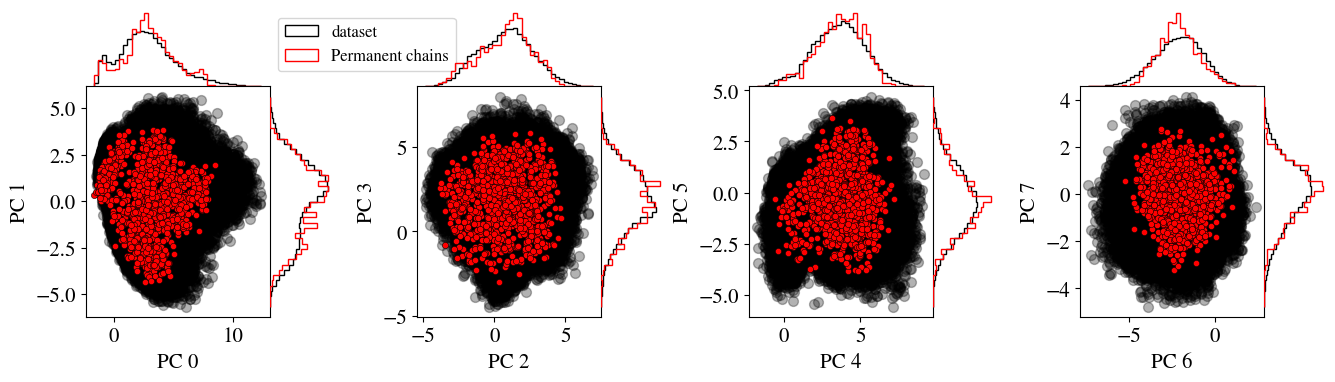

In [7]:
pc_proj = perm_chains["visible"] @ V_dataT.mT
pc_proj = pc_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :8],
    pc_proj[:, :8],
    labels=["dataset", "Permanent chains"],
)

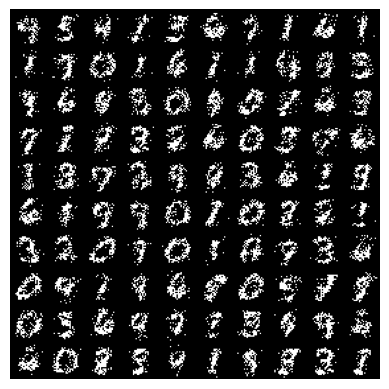

In [8]:
from rbms import plot_image
plot_image(
    perm_chains["visible"].cpu().numpy(),
    shape=(28, 28),
    grid_size=(10, 10),
    randomize=True,
)




# Sample the RBM


(<Figure size 1600x800 with 32 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

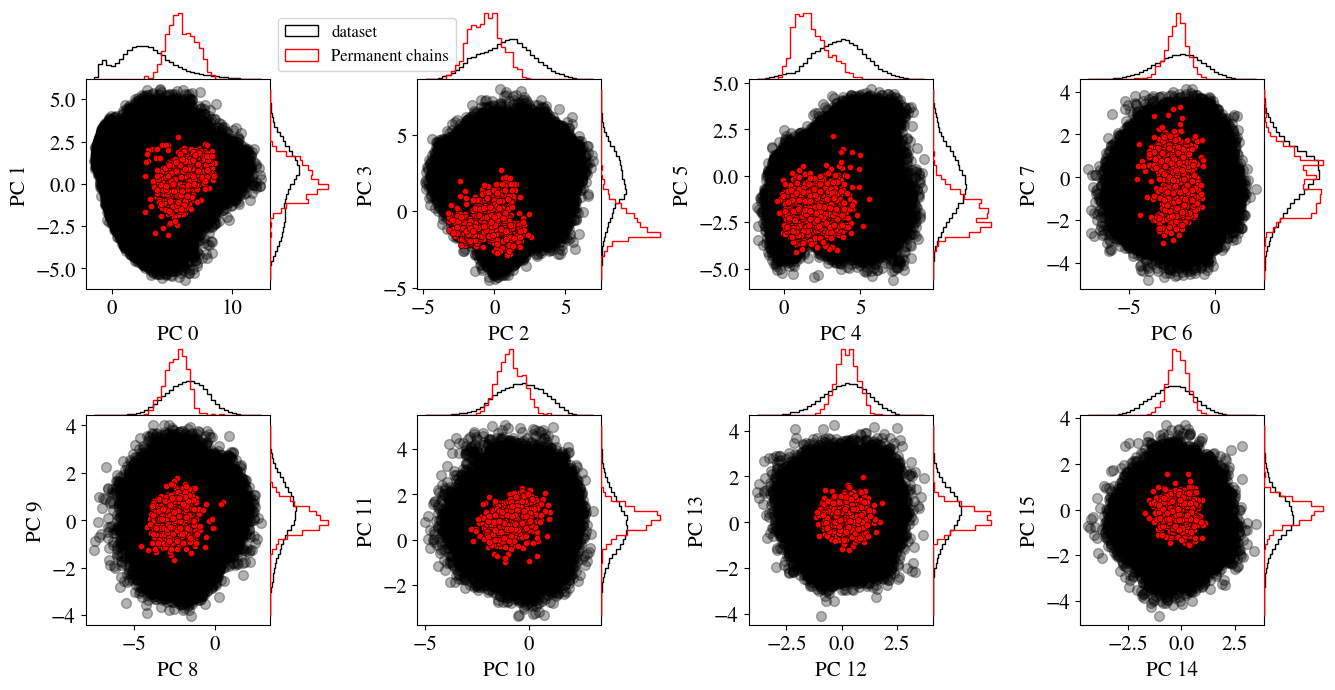

In [9]:
num_samples = 1000
n_steps = 1000


samples = params.init_chains(num_samples=num_samples)
samples = params.sample_state(chains=samples, n_steps=n_steps)

samples_proj = samples["visible"] @ V_dataT.mT
samples_proj = samples_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :16],
    samples_proj[:, :16],
    labels=["dataset", "Permanent chains"],
)

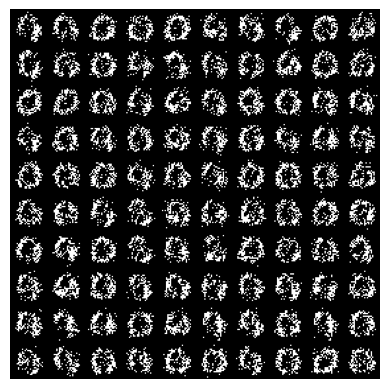

In [10]:
from rbms import plot_image
plot_image(
    samples["visible"].cpu().numpy(),
    shape=(28, 28),
    grid_size=(10, 10),
    randomize=True,
)


In [7]:
from rbms.utils import get_saved_updates

lup = get_saved_updates(filename)
print(lup)


[   1   53  106  158  211  263  316  369  421  474  526  579  631  684
  737  789  842  894  947 1000]


Text(0, 0.5, 'Singular vector value')

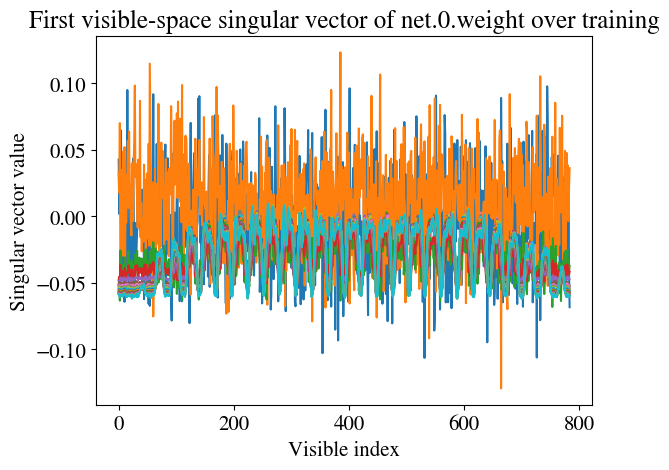

In [8]:
all_u = []
all_s = []

for upd in lup:
    with h5py.File(filename, "r") as f:
        W0 = torch.tensor(
            f[f"update_{upd}"]["params"]["net.0.weight"][()],
            device=device,
            dtype=dtype,
        )

    # PyTorch Linear stores W as (hidden_dim, num_visibles).
    # Transpose so the left singular vectors live in visible/pixel space.
    W_visible = W0.T

    u, s, vh = torch.linalg.svd(W_visible, full_matrices=False)

    all_u.append(u.detach().cpu())
    all_s.append(s.detach().cpu())

    plt.plot(u[:, 0].detach().cpu())

plt.title("First visible-space singular vector of net.0.weight over training")
plt.xlabel("Visible index")
plt.ylabel("Singular vector value")


In [13]:
# from rbms.io import load_params
# from rbms.partition_function.ais import compute_partition_function_ais
# all_LL = []
# # larr = [2,3,5,7,11,15,22,31,44,63,89,125,177,251,354,501,707]
# for upd in np.sort(lup):
#     params = load_params(filename, upd, device, dtype)
#     logZ = compute_partition_function_ais(1000,100,params)
#     LL_tr = compute_log_likelihood(train_dataset.data,torch.ones(train_dataset.data.shape[0]),params,logZ)
#     LL_te = compute_log_likelihood(test_dataset.data,torch.ones(test_dataset.data.shape[0]),params,logZ)
#     all_LL.append([LL_tr,LL_te])
#     print(upd,' ',LL_tr,' ',LL_te)

# Correlation

Lag 0: rho = 1.0000
Lag 1: rho = 0.9754
Lag 2: rho = 0.9545
Lag 3: rho = 0.9358
Lag 4: rho = 0.9185
Lag 5: rho = 0.9022
Lag 6: rho = 0.8868
Lag 7: rho = 0.8723
Lag 8: rho = 0.8584
Lag 9: rho = 0.8451
Lag 10: rho = 0.8324
Lag 11: rho = 0.8201
Lag 12: rho = 0.8083
Lag 13: rho = 0.7969
Lag 14: rho = 0.7859
Lag 15: rho = 0.7753
Lag 16: rho = 0.7651
Lag 17: rho = 0.7551
Lag 18: rho = 0.7455
Lag 19: rho = 0.7362
Lag 20: rho = 0.7271
Lag 21: rho = 0.7183
Lag 22: rho = 0.7097
Lag 23: rho = 0.7013
Lag 24: rho = 0.6932
Lag 25: rho = 0.6852
Lag 26: rho = 0.6775
Lag 27: rho = 0.6699
Lag 28: rho = 0.6626
Lag 29: rho = 0.6553
Lag 30: rho = 0.6483
Lag 31: rho = 0.6414
Lag 32: rho = 0.6346
Lag 33: rho = 0.6280
Lag 34: rho = 0.6215
Lag 35: rho = 0.6152
Lag 36: rho = 0.6090
Lag 37: rho = 0.6029
Lag 38: rho = 0.5970
Lag 39: rho = 0.5911
Lag 40: rho = 0.5854
Lag 41: rho = 0.5798
Lag 42: rho = 0.5743
Lag 43: rho = 0.5689
Lag 44: rho = 0.5636
Lag 45: rho = 0.5584
Lag 46: rho = 0.5533
Lag 47: rho = 0.5483
La

/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_9229/2514304031.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


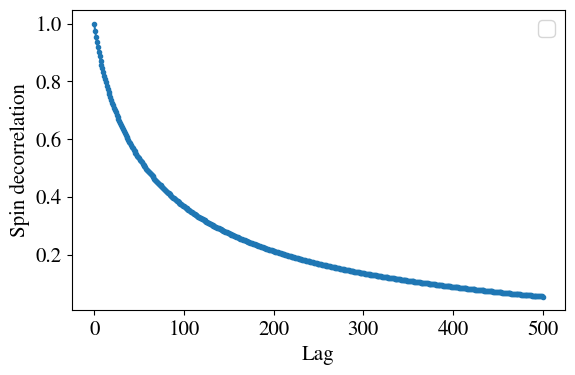

In [31]:
NUM_CHAINS = 512
NUM_STEPS = 1000
MAX_TAU = 500

torch.manual_seed(0)

initial_visible = torch.bernoulli(
    torch.full(
        (NUM_CHAINS, train_dataset.data.shape[1]),
        0.5,
        device=device,
        dtype=dtype,
    )
)

update = saved_updates[-17]

params, perm_chains, _ = load_model(
    filename=filename,
    index=update,
    device=device,
    dtype=dtype,
)

chains = params.init_chains(
    num_samples=NUM_CHAINS,
    start_v=initial_visible,
)

spin_trajectory = []

for step in range(NUM_STEPS + 1):
    visible = chains["visible"].detach()
    spin_trajectory.append(2.0 * visible.cpu() - 1.0)

    if step < NUM_STEPS:
        chains = params.sample_state(chains=chains, n_steps=1)

spins = torch.stack(spin_trajectory, dim=0)

mean_spin = spins.mean(dim=(0, 1))

denominator = (1.0 - mean_spin.pow(2)).sum().clamp_min(1e-12)

lags = torch.arange(MAX_TAU + 1)
rho = []

for tau in lags:
    tau = int(tau)

    s_t = spins[: NUM_STEPS + 1 - tau]
    s_lag = spins[tau:]

    connected = (s_t * s_lag).mean(dim=(0, 1)) - mean_spin.pow(2)
    rho_tau = connected.sum() / denominator

    rho.append(rho_tau)
    print(f"Lag {tau}: rho = {rho_tau.item():.4f}")

rho = torch.stack(rho).numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(lags.numpy(), rho, marker="o", markersize=3)

ax.set_xlabel(r"Lag")
ax.set_ylabel(r"Spin decorrelation")
ax.legend()

plt.tight_layout()

/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_9229/2778818520.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


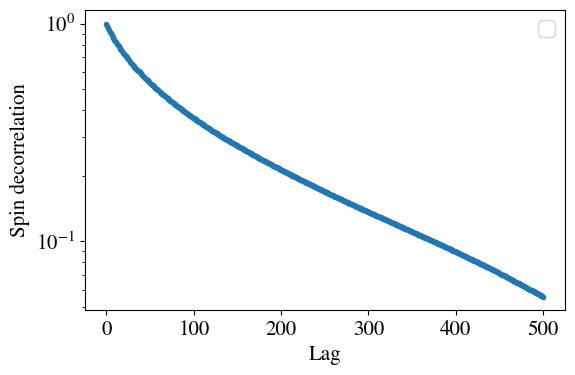

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(lags.numpy(), rho, marker="o", markersize=3)
ax.set_yscale("log")

ax.set_xlabel(r"Lag")
ax.set_ylabel(r"Spin decorrelation")
ax.legend()

plt.tight_layout()


Lag 0: rho_bis = 1.0000
Lag 1: rho_bis = 0.9890
Lag 2: rho_bis = 0.9794
Lag 3: rho_bis = 0.9704
Lag 4: rho_bis = 0.9618
Lag 5: rho_bis = 0.9537
Lag 6: rho_bis = 0.9458
Lag 7: rho_bis = 0.9382
Lag 8: rho_bis = 0.9308
Lag 9: rho_bis = 0.9237
Lag 10: rho_bis = 0.9168
Lag 11: rho_bis = 0.9100
Lag 12: rho_bis = 0.9035
Lag 13: rho_bis = 0.8972
Lag 14: rho_bis = 0.8910
Lag 15: rho_bis = 0.8849
Lag 16: rho_bis = 0.8790
Lag 17: rho_bis = 0.8732
Lag 18: rho_bis = 0.8675
Lag 19: rho_bis = 0.8620
Lag 20: rho_bis = 0.8566
Lag 21: rho_bis = 0.8513
Lag 22: rho_bis = 0.8461
Lag 23: rho_bis = 0.8409
Lag 24: rho_bis = 0.8359
Lag 25: rho_bis = 0.8310
Lag 26: rho_bis = 0.8262
Lag 27: rho_bis = 0.8214
Lag 28: rho_bis = 0.8167
Lag 29: rho_bis = 0.8121
Lag 30: rho_bis = 0.8076
Lag 31: rho_bis = 0.8032
Lag 32: rho_bis = 0.7988
Lag 33: rho_bis = 0.7945
Lag 34: rho_bis = 0.7902
Lag 35: rho_bis = 0.7860
Lag 36: rho_bis = 0.7819
Lag 37: rho_bis = 0.7778
Lag 38: rho_bis = 0.7738
Lag 39: rho_bis = 0.7699
Lag 40: rh

ValueError: x and y must have same first dimension, but have shapes (301,) and (1001,)

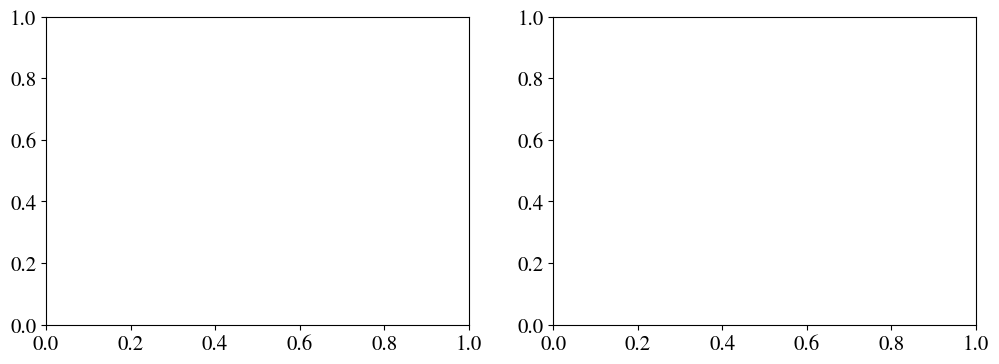

In [ ]:
NUM_MEAN_SAMPLES = 300

mean_spin_bis = spins[-NUM_MEAN_SAMPLES:].mean(dim=(0, 1))
denominator_bis = (1.0 - mean_spin_bis.pow(2)).sum().clamp_min(1e-12)

rho_bis = []

lags = torch.arange(300 + 1)

for tau in lags.tolist():
    s_t = spins[: NUM_STEPS + 1 - tau]
    s_lag = spins[tau:]

    connected_bis = (s_t * s_lag).mean(dim=(0, 1)) - mean_spin_bis.pow(2)
    rho_tau_bis = connected_bis.sum() / denominator_bis

    rho_bis.append(rho_tau_bis)
    print(f"Lag {tau}: rho_bis = {rho_tau_bis.item():.4f}")

rho_bis = torch.stack(rho_bis).cpu().numpy()



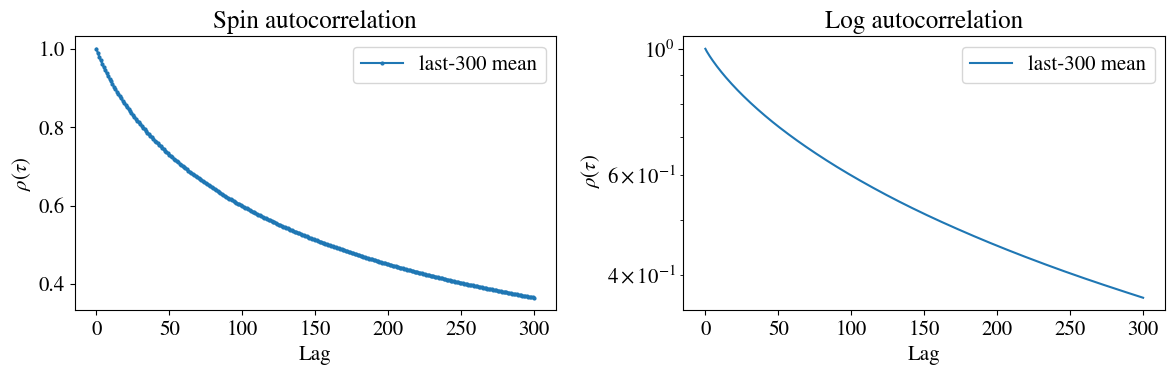

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lags.numpy(), rho_bis, label="last-300 mean", marker="o", markersize=2)
axes[0].set_xlabel("Lag")
axes[0].set_ylabel(r"$\rho(\tau)$")
axes[0].set_title("Spin autocorrelation")
axes[0].legend()

axes[1].plot(lags.numpy(), rho_bis, label="last-300 mean")
axes[1].set_yscale("log")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel(r"$\ \rho(\tau)$")
axes[1].set_title("Log autocorrelation")
axes[1].legend()

plt.tight_layout()


# Log likelihood (Annealed Importance Sampling)

The Log likelihood is given by $$\mathcal{L}_\mathrm{train} = -E(\bm v_\mathrm{train}) - \log Z$$ $$\mathcal{L}_\mathrm{test} = -E(\bm v_\mathrm{test}) - \log Z$$
So we only need to compute $\log Z$ once


In [15]:
# num_chains = 1000
# num_beta = 5000

# ll_train = np.zeros(len(saved_updates))
# ll_test = np.zeros(len(saved_updates))
# for i, upd in tqdm(enumerate(saved_updates), total=len(saved_updates), leave=False):
#     params = load_params(filename, upd, device, dtype)
#     log_z = compute_partition_function_ais(num_chains, num_beta, params)
#     ll_train[i] = compute_log_likelihood(
#         train_dataset.data, train_dataset.weights, params, log_z
#     )
#     ll_test[i] = compute_log_likelihood(
#         test_dataset.data, test_dataset.weights, params, log_z
#     )

NameError: name 'll_train' is not defined

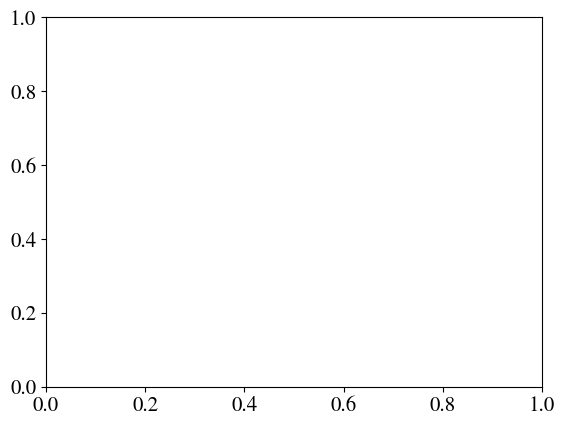

In [16]:
fig, ax = plt.subplots(1, 1)
ax.plot(saved_updates, ll_train, label="Train", color="#BF3B3B")
ax.plot(saved_updates, ll_test, label="Test", ls="--", color="#BF3B3B")
ax.set_xlabel("Training time (gradient updates)")
ax.set_ylabel("LL (nats)")
ax.legend()
ax.semilogx()

# Moment comparison

For each of the moment, we plot its estimation on the train set and on the currently considered dataset.

$m$ corresponds to the directing coefficient of a fitted line

$r$ corresponds to the pearson correlation coefficient between the two estimations


In [ ]:
corr_1b_train = train_dataset.data.mean(0).cpu().numpy()
corr_1b_test = test_dataset.data.mean(0).cpu().numpy()

corr_1b_pc = perm_chains["visible"].mean(0).cpu().numpy()
corr_1b_samples = samples["visible"].mean(0).cpu().numpy()

Text(0.5, 0.98, 'Frequencies')

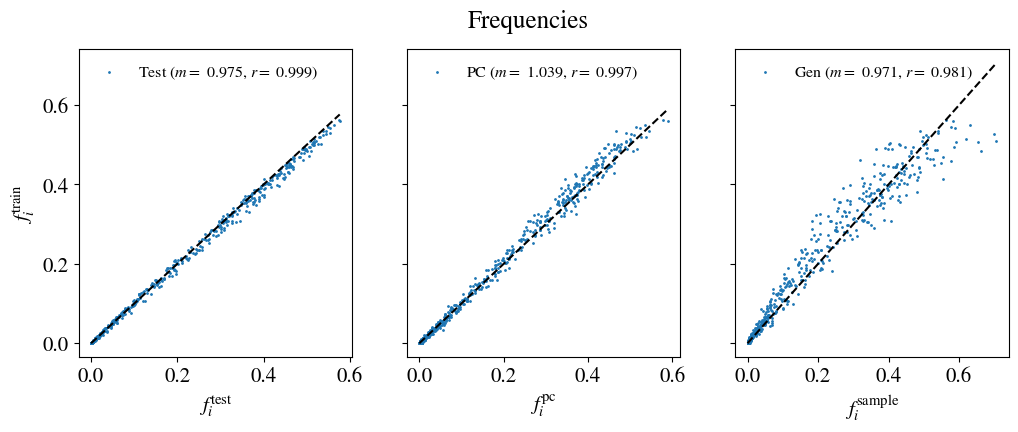

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m1_test, r1_test, x, y, x_line = process_corr(corr_1b_test, corr_1b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m1_test:.3f}, $r=$ {r1_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$f_{i}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$f_{i}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_pc, r1_pc, x, y, x_line = process_corr(corr_1b_pc, corr_1b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m1_pc:.3f}, $r=$ {r1_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$f_{i}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_samples, r1_samples, x, y, x_line = process_corr(corr_1b_samples, corr_1b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m1_samples:.3f}, $r=$ {r1_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$f_{i}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Frequencies")

In [ ]:
corr_2b_train = (
    compute_2b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_test = (
    compute_2b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_pc = (
    compute_2b_correlations(
        perm_chains["visible"].cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
)
corr_2b_samples = (
    compute_2b_correlations(
        samples["visible"].data.cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
)

AssertionError: Torch not compiled with CUDA enabled

Text(0.5, 0.98, 'Covariances')

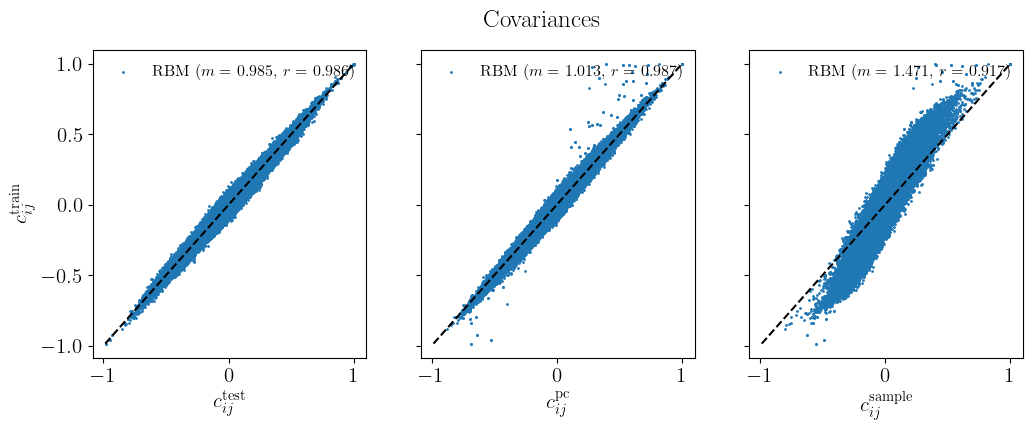

In [ ]:
threshold = 0.0

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

m2_test, r2_test, x, y, x_line = process_corr(corr_2b_test, corr_2b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m2_test:.3f}, $r=$ {r2_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ij}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ij}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_pc, r2_pc, x, y, x_line = process_corr(corr_2b_pc, corr_2b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m2_pc:.3f}, $r=$ {r2_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ij}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_samples, r2_samples, x, y, x_line = process_corr(corr_2b_samples, corr_2b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m2_samples:.3f}, $r=$ {r2_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ij}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Covariances")

In [ ]:
corr_3b_train = (
    compute_3b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_test = (
    compute_3b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_pc = (
    compute_3b_correlations(
        perm_chains["visible"].cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_samples = (
    compute_3b_correlations(
        samples["visible"].data.cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
    .flatten()
)

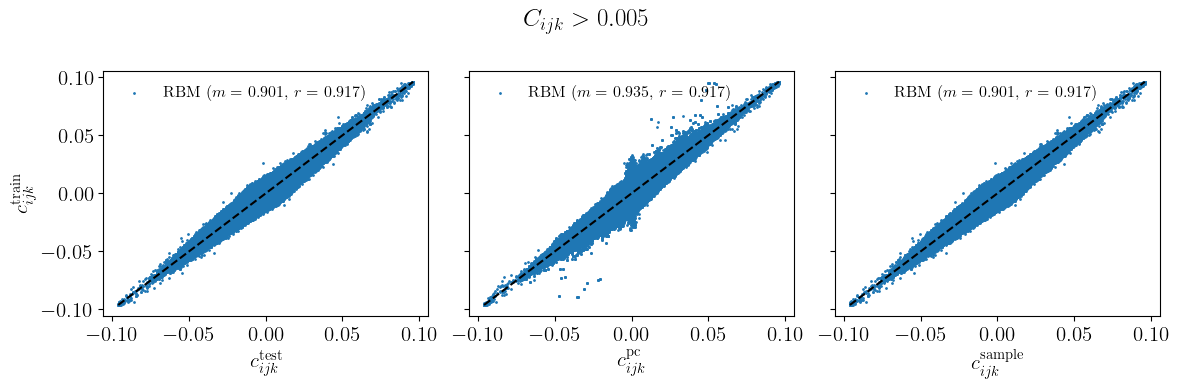

In [ ]:
# Terribly slow because of the number of points to plot

threshold = 0.005
mask = (np.abs(corr_3b_train) > threshold) | (np.abs(corr_3b_test) > threshold)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m3_test, r3_test, x, y, x_line = process_corr(corr_3b_test, corr_3b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m3_test:.3f}, $r=$ {r3_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ijk}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ijk}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_pc, r3_pc, x, y, x_line = process_corr(corr_3b_pc, corr_3b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m3_pc:.3f}, $r=$ {r3_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ijk}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_samples, r3_samples, x, y, x_line = process_corr(corr_3b_samples, corr_3b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m3_samples:.3f}, $r=$ {r3_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ijk}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle(r"$C_{ijk} > 0.005$")
fig.tight_layout()

# Plot images

If your dataset is an image dataset, you can plot images and generated data here


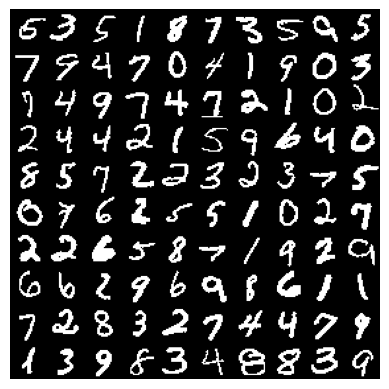

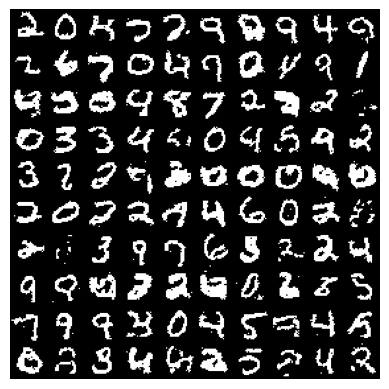

In [ ]:
img_shape = (28, 28)
grid_size = (10, 10)
randomize = True


plot_image(
    train_dataset.data.cpu().numpy(),
    shape=img_shape,
    grid_size=grid_size,
    randomize=randomize,
)

plot_image(
    samples["visible"].cpu().numpy(),
    shape=img_shape,
    grid_size=grid_size,
    randomize=randomize,
)

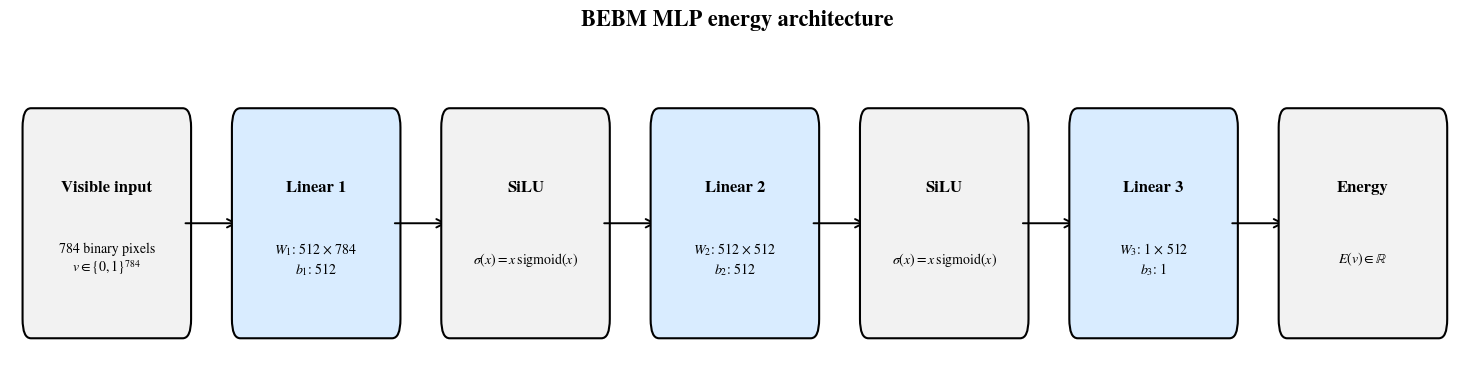

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

layers = [
    ("Visible input", "784 binary pixels\n$v \\in \\{0,1\\}^{784}$"),
    ("Linear 1", "$W_1$: 512 × 784\n$b_1$: 512"),
    ("SiLU", "$\\sigma(x)=x\\,\\mathrm{sigmoid}(x)$"),
    ("Linear 2", "$W_2$: 512 × 512\n$b_2$: 512"),
    ("SiLU", "$\\sigma(x)=x\\,\\mathrm{sigmoid}(x)$"),
    ("Linear 3", "$W_3$: 1 × 512\n$b_3$: 1"),
    ("Energy", "$E(v) \\in \\mathbb{R}$"),
]

fig, ax = plt.subplots(figsize=(15, 4))
ax.axis("off")

x_positions = range(len(layers))
y = 0.5

for i, (title, text) in enumerate(layers):
    box = FancyBboxPatch(
        (i * 2.0, y),
        1.45,
        0.8,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#f2f2f2" if "Linear" not in title else "#d9ecff",
    )
    ax.add_patch(box)

    ax.text(
        i * 2.0 + 0.725,
        y + 0.55,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

    ax.text(
        i * 2.0 + 0.725,
        y + 0.25,
        text,
        ha="center",
        va="center",
        fontsize=10,
    )

    if i < len(layers) - 1:
        arrow = FancyArrowPatch(
            (i * 2.0 + 1.45, y + 0.4),
            ((i + 1) * 2.0, y + 0.4),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.4,
            color="black",
        )
        ax.add_patch(arrow)

ax.set_xlim(-0.2, len(layers) * 2.0 - 0.3)
ax.set_ylim(0.25, 1.55)

fig.suptitle(
    "BEBM MLP energy architecture",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()
plt.show()
